# Exploratory Data Analysis
In this notebook, we will explore the dataset, clean the data, analyze the variables, and find useful insights.


## Importing Libraries

First, we import the libraries needed for the analysis.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

Next, we load the dataset and take a first look at the data.


In [2]:
df = pd.read_csv("/content/car_data.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,NaN,70000.0,Petrrol,NaN,Manual,First Owner
1,Maruti Wagon R LXI Minor,NaN,135000.0,50000.0,Petorl,Indvidual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Deisel,Indvidual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petorl,Indivudal,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesl,Indivudal,Manual,Second Owner


## Data Inspection

Let's take a first look at the dataset and check its structure.


In [3]:
df.shape

(4345, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4017 non-null   object 
 1   year           4041 non-null   float64
 2   selling_price  4054 non-null   float64
 3   km_driven      4026 non-null   object 
 4   fuel           4042 non-null   object 
 5   seller_type    4056 non-null   object 
 6   transmission   4040 non-null   object 
 7   owner          4059 non-null   object 
dtypes: float64(2), object(6)
memory usage: 271.7+ KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,4017,1438,Maruti Swift Dzire VDI,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,4041.0,NaN,NaN,NaN,2013.276417,16.556865,1800.0,2011.0,2014.0,2016.0,3000.0
selling_price,4054.0,NaN,NaN,NaN,502655.413666,580492.958514,-120000.0,200000.0,350000.0,600000.0,8900000.0
km_driven,4026,743,70000.0,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,4042,8,Diesl,1013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,4056,5,Indivudal,1531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4040,2,Manual,3611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,4059,5,First Owner,2654,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()

,0
name,328
year,304
selling_price,291
km_driven,319
fuel,303
seller_type,289
transmission,305
owner,286


In [7]:
df.duplicated().sum()

np.int64(112)

In [8]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


name:
['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']

km_driven:
['70000.0' '50000.0' '100000.0' '46000.0' '141000.0' nan '60000.0'
 '25000.0' '78000.0' '35000.0' '125000.0' '24000.0' '5000.0' '33000.0'
 '28000.0' '59000.0' '4500.0' '175900.0' '14500.0' '33800.0' '80000.0'
 '10000.0' '119000.0' '75800.0' '40000.0' '74000.0' '64000.0' '120000.0'
 '79000.0' '15000.0' '18500.0' '10200.0' '29000.0' '90000.0' '92000.0'
 '66764.0' '350000.0' '230000.0' '31000.0' '39000.0' '166000.0' '110000.0'
 '54000.0' '63000.0' '76000.0' '11958.0' '20000.0' '9000.0' '6500.0'
 '58000.0' '62200.0' '34000.0' '53000.0' '49000.0' '63500.0' '21000.0'
 '29173.0' '30000.0' '87000.0' '16000.0' '3600.0' '14272.0' '57000.0'
 '3240.0' '114000.0' '53772.0' '140000.0' '175000.0' '155500.0' '22155.0'
 '78380.0' '150000.0' '80362.0' '55000.0' '1136.0' '43000.0' '2650.0'
 '115962.0' '6500

## Data Cleaning

Now, we clean the dataset by handling duplicates, invalid values, missing values, and inconsistent categories.


### Removing Duplicates

We found duplicate rows in the dataset, so we remove them before continuing the analysis.


In [9]:
df_clean = df.copy()

In [11]:
df_clean = df.drop_duplicates().copy()
#نحذف التكرر

In [13]:
df_clean.duplicated().sum()
#نتاكد اننا حذفنا

np.int64(0)

In [14]:
df_clean.shape

(4233, 8)

### Standardizing Categorical Values

Some categorical values contain spelling inconsistencies, so we standardize them into consistent categories.


In [15]:
fuel_map = {
    'Petrrol': 'Petrol',
    'Petorl': 'Petrol',
    'Petrl': 'Petrol',
    'Deisel': 'Diesel',
    'Diesl': 'Diesel'
}

df_clean['fuel'] = df_clean['fuel'].replace(fuel_map)

In [16]:
seller_map = {
    'Indvidual': 'Individual',
    'Indivudal': 'Individual',
    'Deelar': 'Dealer',
    'Dealerr': 'Dealer'
}

df_clean['seller_type'] = df_clean['seller_type'].replace(seller_map)

In [20]:
df_clean['fuel'].unique()


array(['Petrol', 'Diesel', 'CNG', nan, 'LPG', 'Electric'], dtype=object)

In [21]:
df_clean['seller_type'].unique()

array([nan, 'Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

### Cleaning `km_driven`

The `km_driven` column contains inconsistent values such as text and units. We clean these values and convert the column into a numeric format.


In [26]:
df_clean['km_driven'] = (
    df_clean['km_driven']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('km', '', regex=False)
)

In [27]:
mask = df_clean['km_driven'].str.endswith('k', na=False)

df_clean.loc[mask, 'km_driven'] = (
    df_clean.loc[mask, 'km_driven']
    .str[:-1]
    .astype(float)
    .mul(1000)
)

In [28]:
df_clean['km_driven'] = pd.to_numeric(
    df_clean['km_driven'],
    errors='coerce'
)

In [29]:
df_clean['km_driven'].dtype

dtype('float64')

In [30]:
df_clean['km_driven'].head()

,km_driven
0,70000.0
1,50000.0
2,100000.0
3,46000.0
4,141000.0


### Cleaning `year`

The `year` column contains some invalid values that do not represent realistic car manufacturing years. We identify and handle these values before continuing the analysis.


In [31]:
df_clean.loc[
    (df_clean['year'] < 1900) | (df_clean['year'] > 2026),
    'year'
]

,year
997,1890.0
1651,1800.0
2866,3000.0
4037,2050.0


In [32]:
df_clean.loc[
    (df_clean['year'] < 1900) | (df_clean['year'] > 2026),
    'year'
] = np.nan

In [33]:
df_clean['year'].min(), df_clean['year'].max()

(1992.0, 2020.0)

### Cleaning `selling_price`

The `selling_price` column contains an invalid negative value. We replace invalid prices with missing values instead of removing the entire rows.


In [34]:
df_clean.loc[df_clean['selling_price'] < 0, 'selling_price'] = np.nan

In [35]:
df_clean['selling_price'].min()

20000.0

In [36]:
df_clean.isnull().sum()

,0
name,326
year,307
selling_price,293
km_driven,321
fuel,299
seller_type,289
transmission,304
owner,284


### Handling Missing Values

Missing values are present in both numerical and categorical columns. We keep missing numerical values as `NaN` and replace missing categorical values with `Unknown`.


In [37]:
categorical_cols = [
    'name',
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

df_clean[categorical_cols] = df_clean[categorical_cols].fillna('Unknown')

In [38]:
df_clean.isnull().sum()

,0
name,0
year,307
selling_price,293
km_driven,321
fuel,0
seller_type,0
transmission,0
owner,0


### Final Cleaning Check

Finally, we check the dataset again to make sure the main data quality issues have been handled successfully.


In [47]:
df_clean.duplicated().sum()

np.int64(0)

In [48]:
df_clean = df_clean.drop_duplicates().copy()

In [49]:
df_clean.duplicated().sum()

np.int64(0)

In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4032 entries, 0 to 4232
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4032 non-null   object 
 1   year           3727 non-null   float64
 2   selling_price  3740 non-null   float64
 3   km_driven      3714 non-null   float64
 4   fuel           4032 non-null   object 
 5   seller_type    4032 non-null   object 
 6   transmission   4032 non-null   object 
 7   owner          4032 non-null   object 
dtypes: float64(3), object(5)
memory usage: 283.5+ KB


In [42]:
df_clean = df_clean.reset_index(drop=True)

In [51]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3727.0,2013.055272,4.228847,1992.0,2011.0,2014.0,2016.0,2020.0
selling_price,3740.0,483852.716578,536294.673456,20000.0,200000.0,350000.0,600000.0,8900000.0
km_driven,3714.0,89845.170705,881339.584901,1.0,35000.0,60000.0,90000.0,50000000.0


In [52]:
df_clean.isnull().sum()

,0
name,0
year,305
selling_price,292
km_driven,318
fuel,0
seller_type,0
transmission,0
owner,0


## Feature Engineering

We create new features from the existing data to make the analysis more meaningful and easier to interpret.


In [53]:
df_clean['car_age'] = 2020 - df_clean['year']

In [54]:
df_clean[['year', 'car_age']].head()

,year,car_age
0,2007.0,13.0
1,NaN,NaN
2,2012.0,8.0
3,2017.0,3.0
4,2014.0,6.0


### Extracting Car Brand

We extract the car brand from the `name` column to make brand-level analysis easier.


In [55]:
df_clean['brand'] = df_clean['name'].str.split().str[0]

In [56]:
df_clean[['name', 'brand']].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


## Univariate Analysis

Now, we analyze each variable separately to understand its distribution and identify any unusual values.


### Selling Price

Let's look at the distribution of selling prices and check for any unusual values.


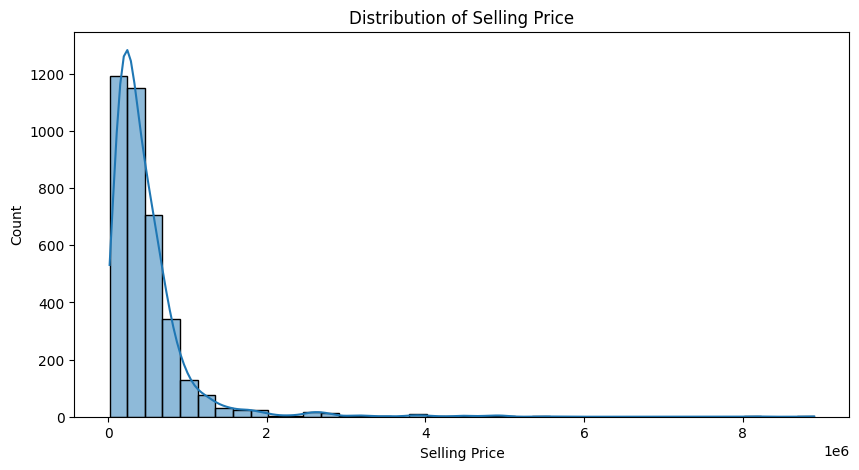

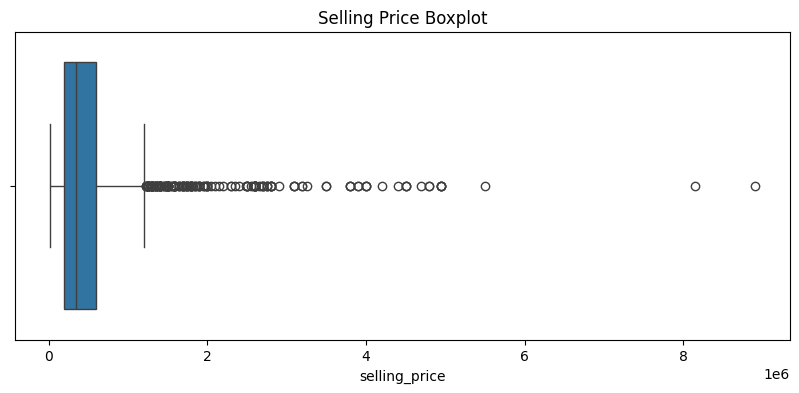

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['selling_price'].dropna(), bins=40, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['selling_price'])
plt.title('Selling Price Boxplot')
plt.show()

### Kilometers Driven

Let's examine the distribution of kilometers driven and check for possible outliers.


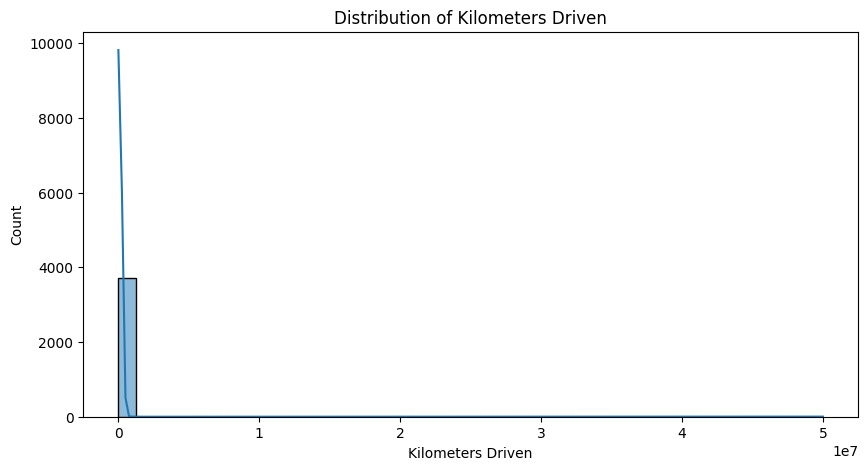

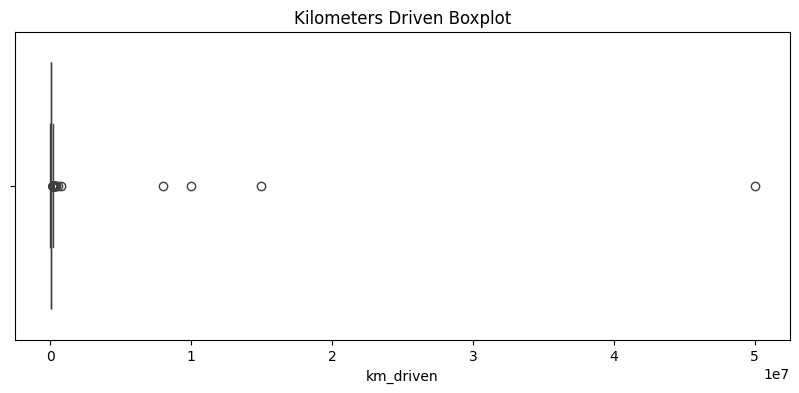

In [58]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['km_driven'].dropna(), bins=40, kde=True)
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['km_driven'])
plt.title('Kilometers Driven Boxplot')
plt.show()

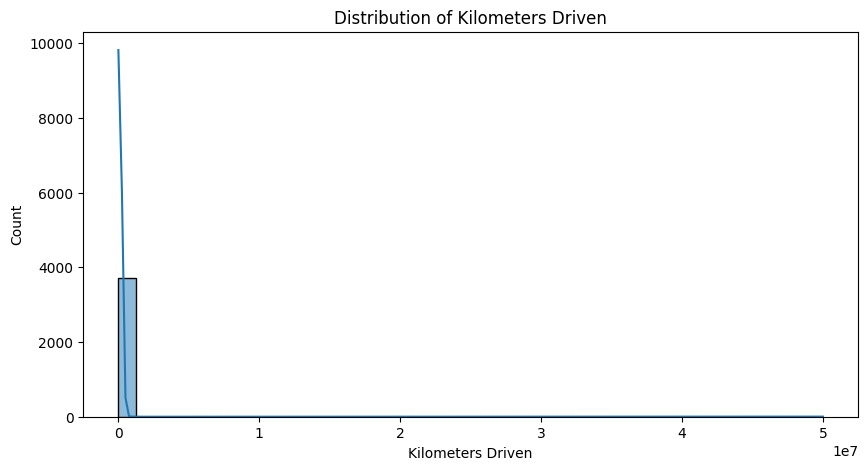

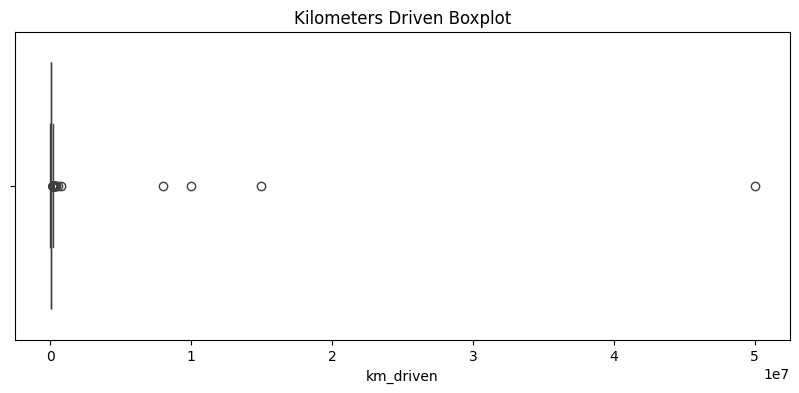

In [60]:
df_clean['km_driven'].describe()

,km_driven
count,3.714000e+03
mean,8.984517e+04
std,8.813396e+05
min,1.000000e+00
25%,3.500000e+04
50%,6.000000e+04
75%,9.000000e+04
max,5.000000e+07


### Insight

Most cars have relatively moderate mileage, with a median of 60,000 km and 75% of the values below 90,000 km. The maximum value of 50,000,000 km is extremely high compared to the rest of the data, indicating potential outliers.

In [61]:
df_clean['year'].describe()

,year
count,3727.000000
mean,2013.055272
std,4.228847
min,1992.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2020.000000


### Insight

Most cars in the dataset were manufactured between 2011 and 2016, with a median year of 2014. The dataset covers cars manufactured from 1992 to 2020.

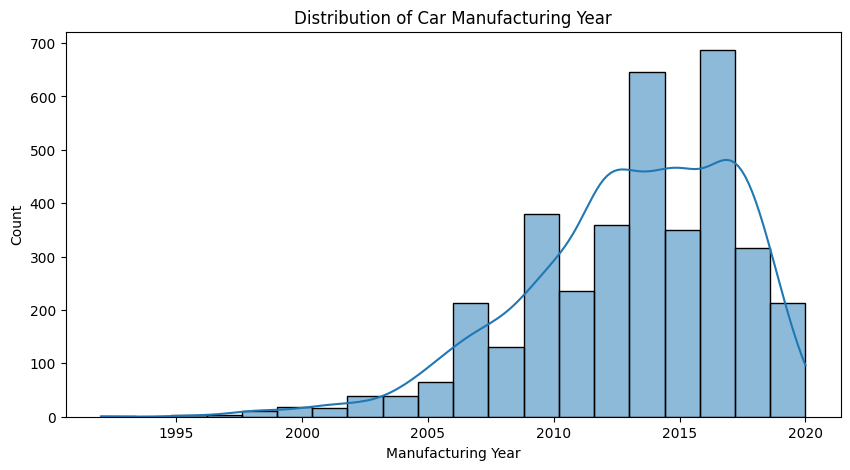

In [62]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean['year'].dropna(),
    bins=20,
    kde=True
)

plt.title('Distribution of Car Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Count')
plt.show()

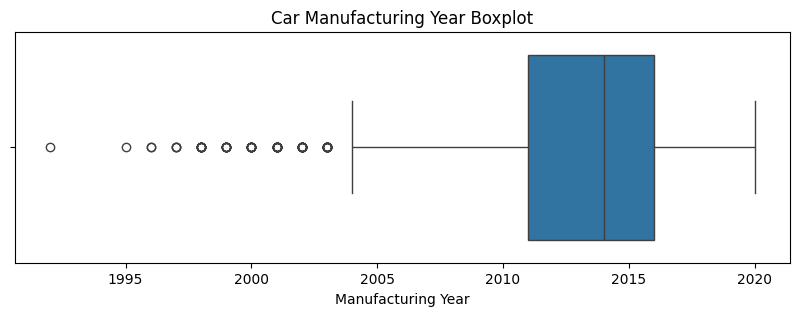

In [63]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df_clean['year'])

plt.title('Car Manufacturing Year Boxplot')
plt.xlabel('Manufacturing Year')
plt.show()

In [64]:
df_clean['car_age'].describe()

,car_age
count,3727.000000
mean,6.944728
std,4.228847
min,0.000000
25%,4.000000
50%,6.000000
75%,9.000000
max,28.000000


### Insight

Most cars are relatively recent, with a median age of 6 years. About 75% of the cars are 9 years old or less, while the oldest car is 28 years old.

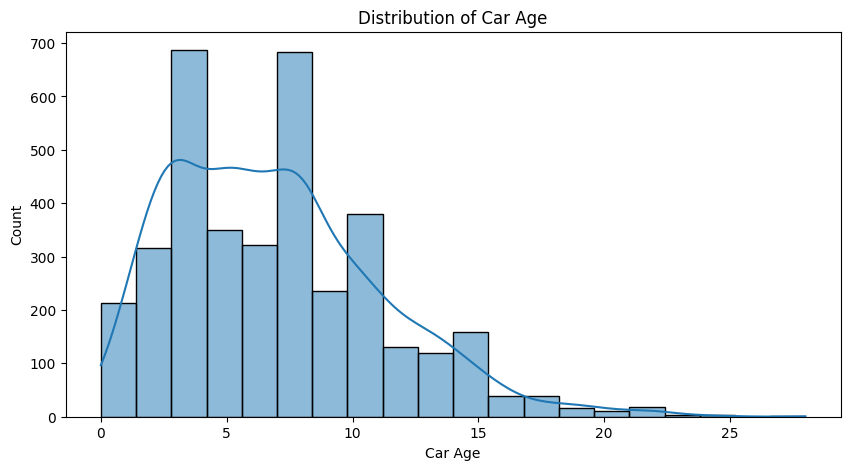

In [65]:
plt.figure(figsize=(10, 5))

sns.histplot(df_clean['car_age'].dropna(), bins=20, kde=True)

plt.title('Distribution of Car Age')
plt.xlabel('Car Age')
plt.ylabel('Count')
plt.show()

### Fuel Type

Let's examine the distribution of cars by fuel type.

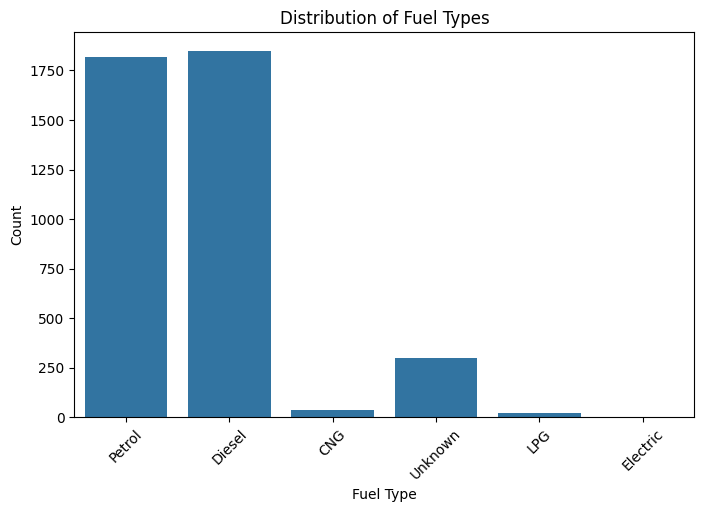

In [66]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x='fuel')

plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Insight

Diesel and Petrol are the most common fuel types, with 1,850 and 1,820 cars respectively. CNG and LPG are much less common, while Electric cars are almost absent from the dataset. There are also 299 records with unknown fuel type.

In [67]:
df_clean['fuel'].value_counts()

,count
fuel,
Diesel,1850
Petrol,1820
Unknown,299
CNG,39
LPG,23
Electric,1


In [68]:
df_clean['seller_type'].value_counts()

,count
seller_type,
Individual,2891
Dealer,797
Unknown,287
Trustmark Dealer,57


### Insight

Individual sellers dominate the dataset with 2,891 cars, while dealers account for 797 cars. Trustmark Dealers represent a small portion of the data, and 287 records have an unknown seller type.

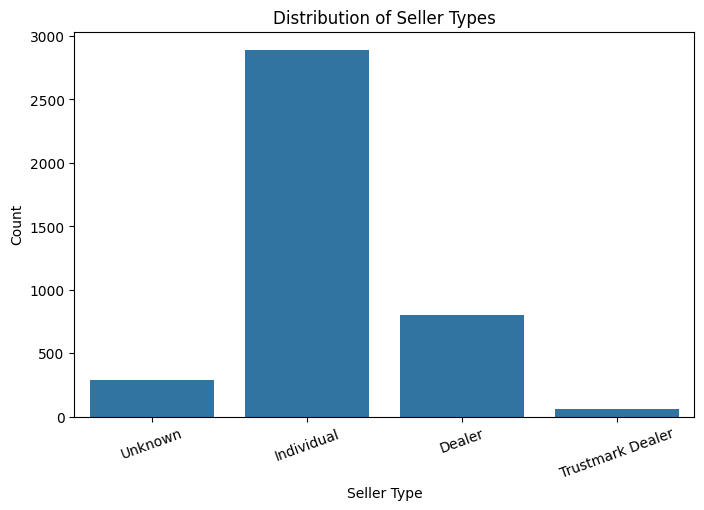

In [69]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x='seller_type')

plt.title('Distribution of Seller Types')
plt.xlabel('Seller Type')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

In [70]:
df_clean['transmission'].value_counts()

,count
transmission,
Manual,3372
Automatic,362
Unknown,298


### Insight

Manual transmission cars dominate the dataset with 3,372 records, while automatic cars account for only 362 records. There are also 298 records with an unknown transmission type.

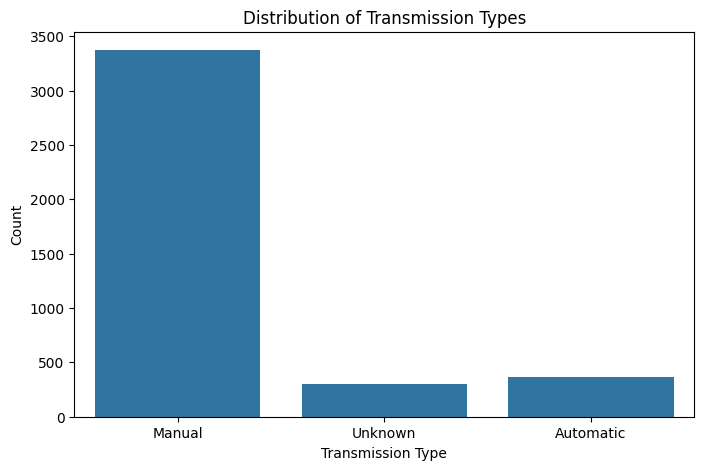

In [71]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x='transmission')

plt.title('Distribution of Transmission Types')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

In [72]:
df_clean['owner'].value_counts()

,count
owner,
First Owner,2412
Second Owner,977
Unknown,281
Third Owner,274
Fourth & Above Owner,71
Test Drive Car,17


### Insight

First Owner cars dominate the dataset with 2,412 records, followed by Second Owner cars with 977 records. Cars with three or more previous owners are much less common, while 281 records have an unknown owner type.

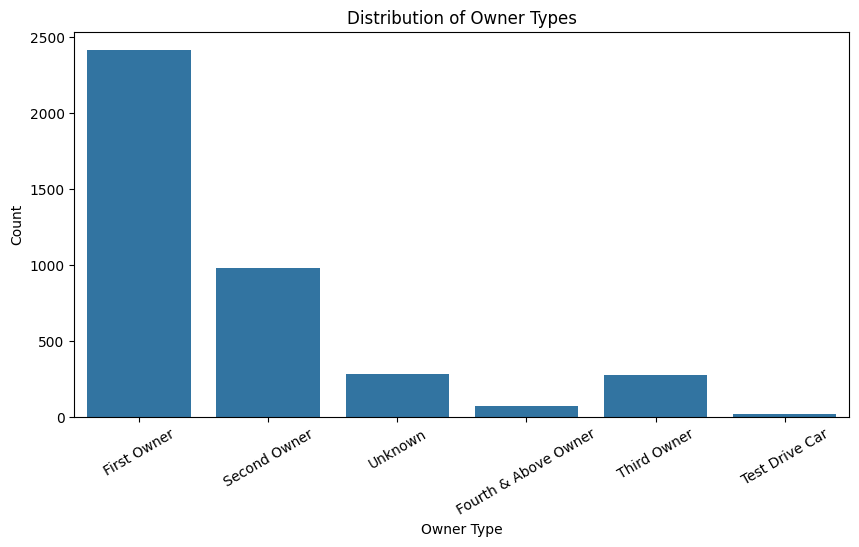

In [73]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df_clean, x='owner')

plt.title('Distribution of Owner Types')
plt.xlabel('Owner Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [74]:
df_clean['brand'].value_counts().head(10)

,count
brand,
Maruti,1108
Hyundai,674
Unknown,326
Tata,316
Mahindra,315
Honda,222
Ford,216
Toyota,181
Chevrolet,160


### Insight

Maruti is the most common brand in the dataset with 1,108 cars, followed by Hyundai with 674 cars. Tata and Mahindra have similar representation, while the remaining brands appear less frequently. There are also 326 records with an unknown brand.

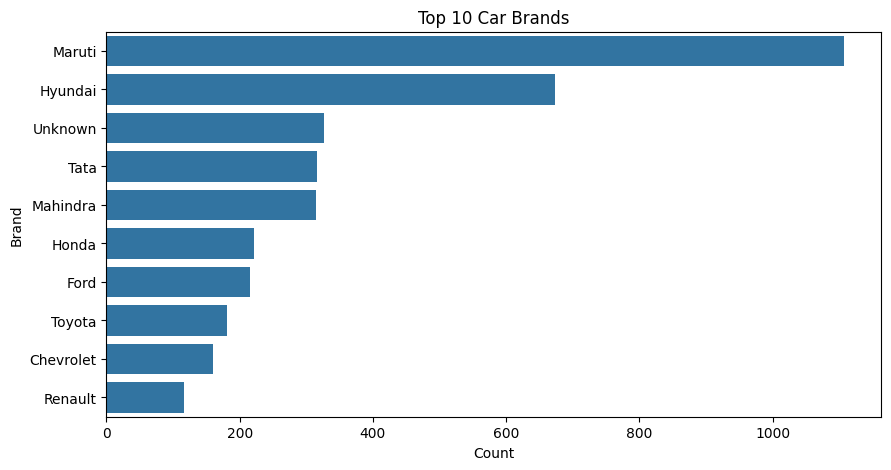

In [75]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    y='brand',
    order=df_clean['brand'].value_counts().head(10).index
)

plt.title('Top 10 Car Brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.show()

## Bivariate Analysis

Now, we examine the relationships between two variables to identify useful patterns.

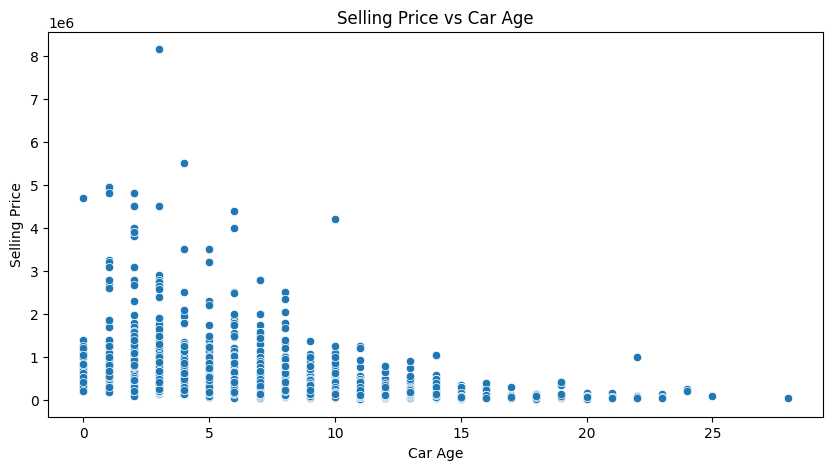

In [76]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df_clean, x='car_age', y='selling_price')

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')
plt.show()

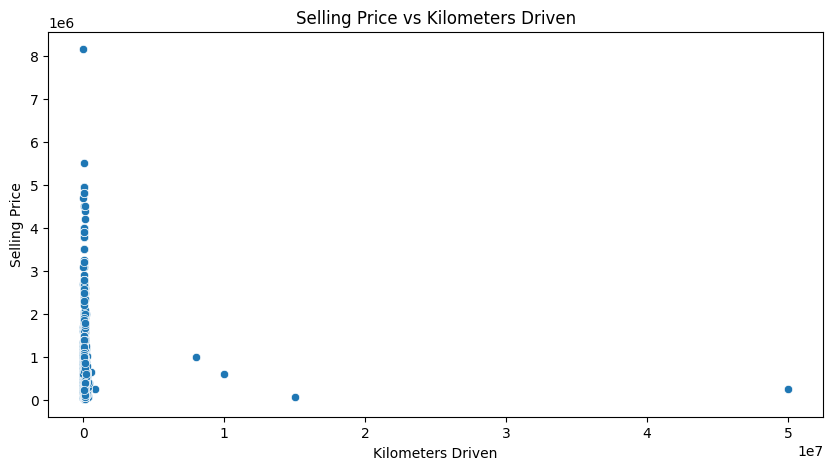

In [77]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df_clean, x='km_driven', y='selling_price')

plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()

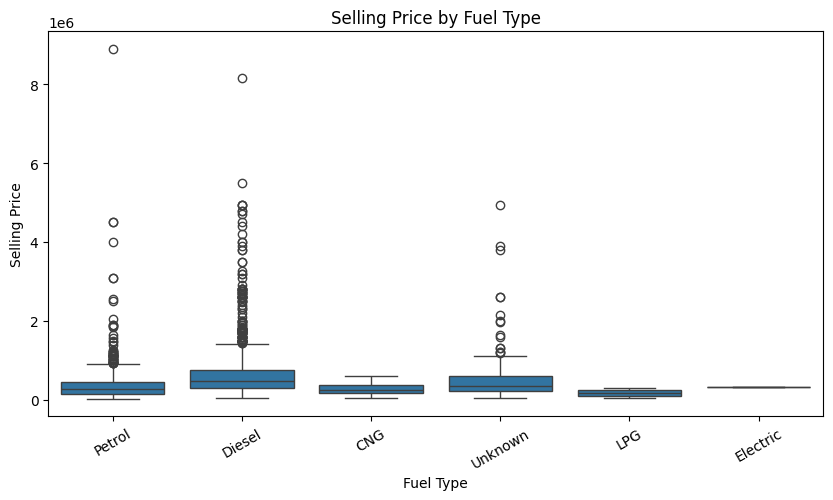

In [78]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_clean, x='fuel', y='selling_price')

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=30)
plt.show()

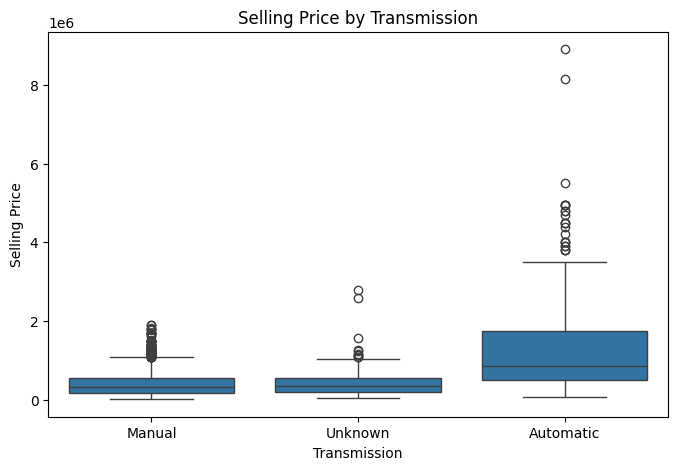

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x='transmission', y='selling_price')

plt.title('Selling Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.show()

## Multivariate Analysis

Now, we analyze multiple variables together to understand the overall relationships in the dataset.

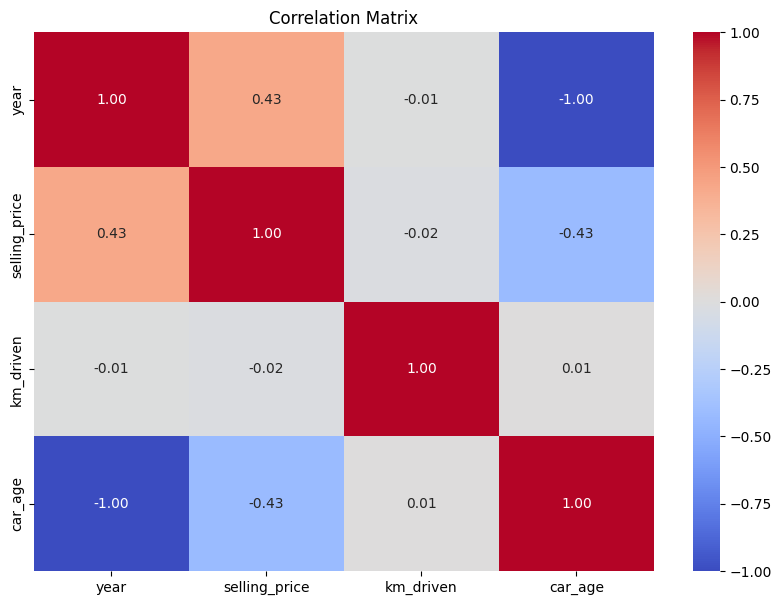

In [80]:
plt.figure(figsize=(10, 7))

corr = df_clean[
    ['year', 'selling_price', 'km_driven', 'car_age']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

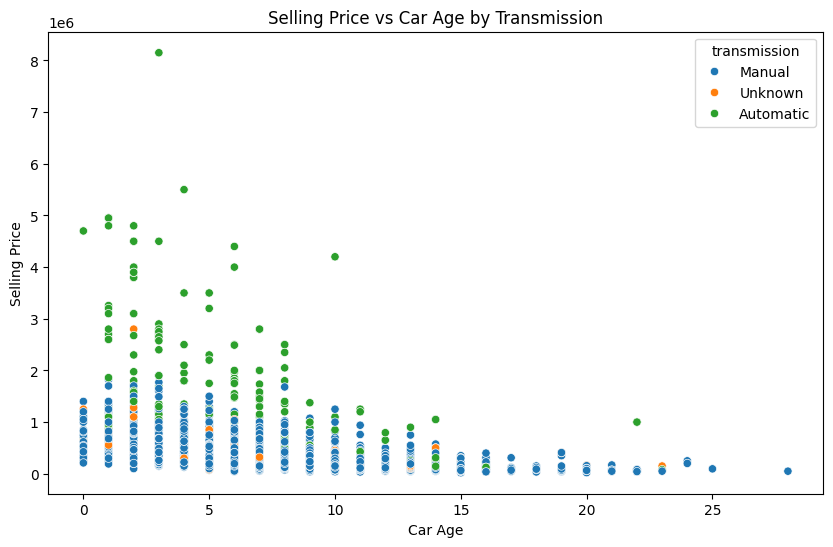

In [81]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='car_age',
    y='selling_price',
    hue='transmission'
)

plt.title('Selling Price vs Car Age by Transmission')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')
plt.show()

## Final Insights

- The dataset contains 4,032 car records after cleaning.
- Diesel and Petrol are the dominant fuel types.
- Individual sellers represent the majority of listings.
- Manual transmission cars are much more common than automatic cars.
- First Owner cars are the most common owner type.
- Maruti is the most represented brand.
- Most cars have a median age of 6 years.
- The dataset contains some extreme values, especially in kilometers driven.